<a id="inicio"></a>

# Formula 1 Data Analysis

## Objective

Explore nearly 75 years of Formula 1 history (1950–present) to answer general competitive questions and track the career trajectory of driver Fernando Alonso against his rivals. The dataset is sourced from [ergast.com](http://ergast.com/mrd/), a reference F1 database.

## Methodology

- **Data Ingestion**: Load 13 related CSV files (drivers, races, results, circuits, constructors, status, and more)
- **Data Cleaning**: Type conversion, missing value handling (`\N` sentinels), temporal feature construction
- **Relational Analysis**: DataFrame merges across drivers, races, results, constructors, and circuits
- **Head-to-Head Analysis**: Compare Alonso's performance against each rival he has faced on track
- **Visualization**: Bar charts, horizontal bar charts, pie charts, and geographic circuit maps with Folium

---

<a id="indice"></a>
## Contents

* [1. Introduction](#section1)
* [2. Drivers](#section2)
* [3. Races and Results](#section3)
* [4. Constructors](#section4)
* [5. Circuits](#section5)
* [6. Fernando Alonso vs Rivals](#section6)
* [7. Conclusions](#section7)

---

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container {width:99%} </style>"))
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import style
style.use('seaborn-v0_8')

<a id="section1"></a>
## 1. Introduction

This project analyzes Formula 1 race data covering every season from 1950 to the present. The dataset is sourced from [ergast.com](http://ergast.com/mrd/), which maintains a comprehensive F1 database and distributes the data either via an API or as a bundle of 14 CSV files.

The analysis answers a set of general competitive questions and, as a more concrete goal, provides a view of Spanish driver Fernando Alonso's career trajectory in the sport. The work is deliberately focused on applied data manipulation — exercising `pandas` (and some `matplotlib`) across a realistic relational dataset with joins, groupings, and filtering across multiple files.

<div align="right">
<a href="#indice">[back to contents]</a>
</div>

---

<a id="section2"></a>
## 2. Drivers

The file `data/drivers.csv` contains basic identification information for each driver. Since the project centers on a specific driver — Fernando Alonso — this table is the natural starting point.

### Loading the drivers file

Load `data/drivers.csv` into a DataFrame named `df_drivers` and inspect its header and structure.

In [2]:
ls

Capstone I.ipynb              data/
Formula1_Data_Analysis.ipynb


In [3]:
df_drivers = pd.read_csv('data/drivers.csv')
df_drivers.head()

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [4]:
df_drivers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   driverId     860 non-null    int64 
 1   driverRef    860 non-null    object
 2   number       860 non-null    object
 3   code         860 non-null    object
 4   forename     860 non-null    object
 5   surname      860 non-null    object
 6   dob          860 non-null    object
 7   nationality  860 non-null    object
 8   url          860 non-null    object
dtypes: int64(1), object(8)
memory usage: 60.6+ KB


Looking at the DataFrame, the `driverId` column is an integer identifier while the rest of the columns default to `object`, including `number` and the date of birth `dob`. Nationality is a good candidate for a categorical dtype. Rather than fixing this after the fact with `set_index()` and `astype()`, we simply reload the file with the right settings.

Reload `data/drivers.csv` using `driverId` as the index, declaring `\N` as the missing-value sentinel, casting `driverRef`, `code`, `forename`, and `surname` to `string`, `nationality` to `category`, and parsing `dob` as a date.

In [5]:
new_types = {
       'driverRef': 'string',
       'code': 'string',
       'forename': 'string',
       'surname': 'string',
       'nationality': 'category'
   }

df_drivers = pd.read_csv('data/drivers.csv',
   index_col='driverId',
   na_values='\\N',
   dtype= new_types,
   parse_dates=['dob']
)

df_drivers.head()

,driverRef,number,code,forename,surname,dob,nationality,url
driverId,,,,,,,,
1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
4,alonso,14.0,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
5,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [6]:
df_drivers.dtypes
df_drivers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 860 entries, 1 to 861
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   driverRef    860 non-null    string        
 1   number       58 non-null     float64       
 2   code         103 non-null    string        
 3   forename     860 non-null    string        
 4   surname      860 non-null    string        
 5   dob          860 non-null    datetime64[ns]
 6   nationality  860 non-null    category      
 7   url          860 non-null    object        
dtypes: category(1), datetime64[ns](1), float64(1), object(1), string(4)
memory usage: 56.0+ KB


Extract the row corresponding to Fernando Alonso (code `ALO`) into a Series named `alonso_data`, and store his driver ID in `alonso_id`.

In [7]:
alonso_id = df_drivers[df_drivers['code'] == 'ALO'].index[0]
alonso_data = df_drivers.loc[alonso_id]

In [8]:
youngest_drivers = df_drivers.sort_values('dob', ascending=False).head()
print(youngest_drivers)

          driverRef  number code forename    surname        dob  \
driverId                                                          
860         bearman    38.0  BEA   Oliver    Bearman 2005-05-08   
861       colapinto    43.0  COL   Franco  Colapinto 2003-05-27   
859          lawson    40.0  LAW     Liam     Lawson 2002-02-11   
857         piastri    81.0  PIA    Oscar    Piastri 2001-04-06   
858        sargeant     2.0  SAR    Logan   Sargeant 2000-12-31   

            nationality                                            url  
driverId                                                                
860             British    http://en.wikipedia.org/wiki/Oliver_Bearman  
861        Argentinian   http://en.wikipedia.org/wiki/Franco_Colapinto  
859       New Zealander       http://en.wikipedia.org/wiki/Liam_Lawson  
857          Australian     http://en.wikipedia.org/wiki/Oscar_Piastri  
858            American    http://en.wikipedia.org/wiki/Logan_Sargeant  


### Driver nationalities

Using `matplotlib`, build a bar chart showing the number of drivers per nationality for the top 20 nations in the dataset.

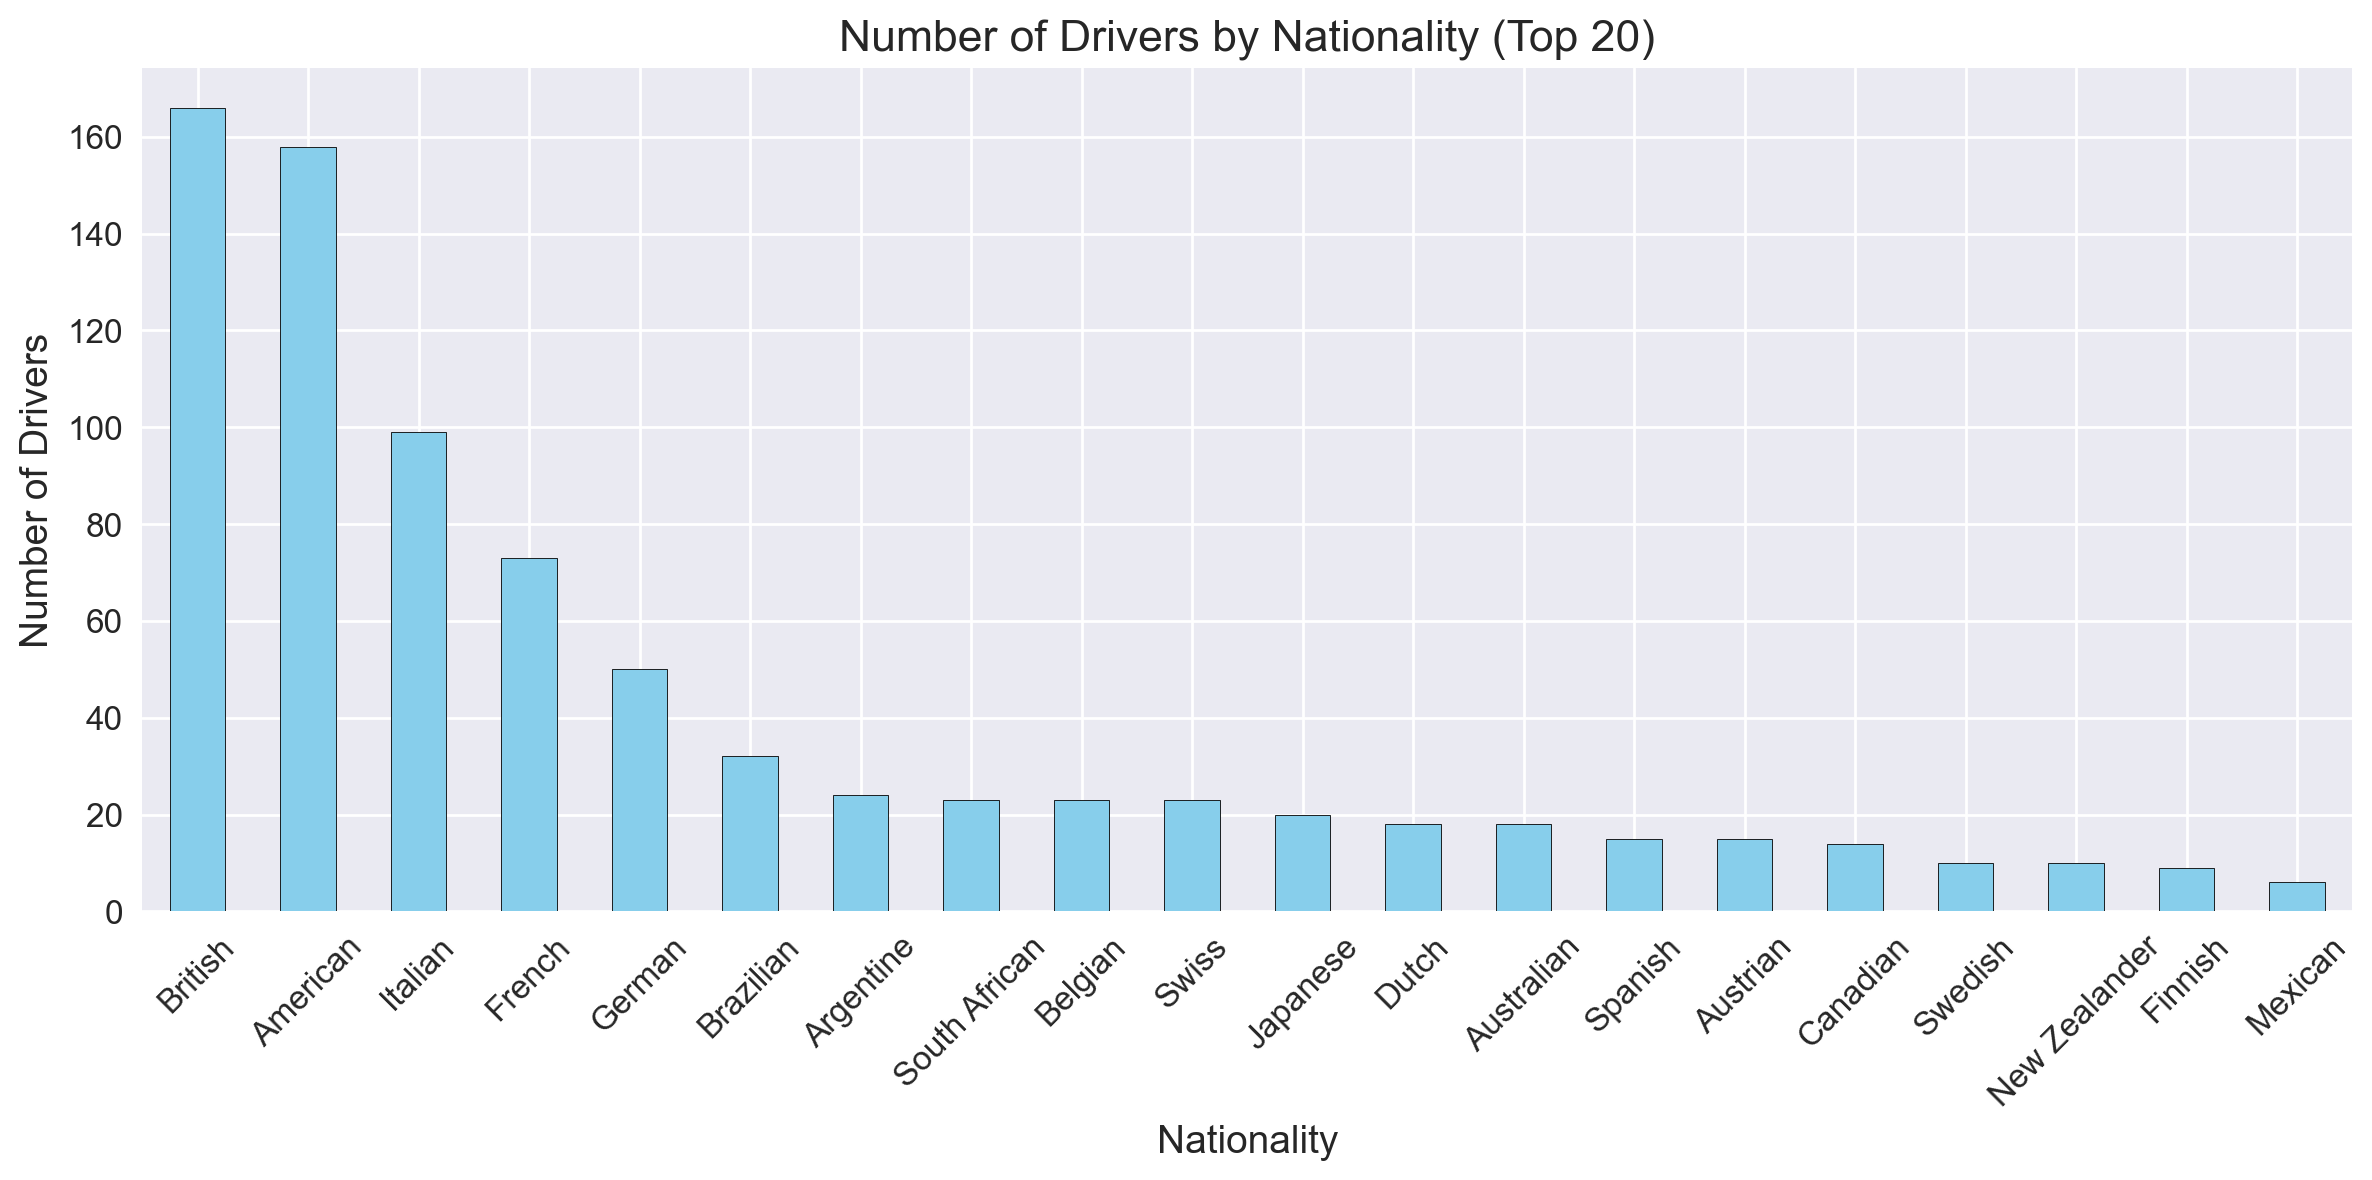

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

top_nationalities = df_drivers['nationality'].value_counts().head(20)

plt.figure(figsize=(12, 6))
top_nationalities.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Drivers by Nationality (Top 20)', fontsize=16)
plt.xlabel('Nationality', fontsize=14)
plt.ylabel('Number of Drivers', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

<div align="right">
<a href="#indice">[back to contents]</a>
</div>

---

<a id="section3"></a>
## 3. Races and Results

With drivers processed, we turn to the most important data in the set: race metadata and race results.

### Loading the races file

The file `data/races.csv` holds general race-level information — name, circuit, date, etc. We load it using `raceId` as the index and parse `date` as a datetime.

In [10]:
df_races = pd.read_csv(
    'data/races.csv',
    index_col='raceId',
    parse_dates=['date']
)

df_races.head()

,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
raceId,,,,,,,,,,,,,,,,,
1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


Inspect the DataFrame. How many missing values does the `time` column have?

In [11]:
unique_times = df_races['time'].unique()
print("Unique values in the 'time' column:")
print(unique_times)

Unique values in the 'time' column:
['06:00:00' '09:00:00' '07:00:00' '12:00:00' '05:00:00' '16:00:00'
 '11:00:00' '04:30:00' '11:30:00' '17:00:00' '03:00:00' '14:30:00'
 '15:00:00' '14:00:00' '13:00:00' '\\N' '08:00:00' '09:30:00' '18:00:00'
 '19:00:00' '20:00:00' '05:10:00' '15:10:00' '06:10:00' '12:10:00'
 '13:10:00' '18:10:00' '14:10:00' '11:10:00' '19:10:00' '17:10:00'
 '10:10:00' '17:30:00' '19:30:00' '04:00:00']


In [12]:
missing_time = (df_races['time'] == '\\N').sum()
print(f"Missing values in the 'time' column (represented by '\\N'): {missing_time}")

Missing values in the 'time' column (represented by '\N'): 731


The `time` column is stored as a string. Convert the values to timestamps and inspect the result. What date does pandas infer when the string only has a time component?

In [13]:
pd.to_datetime(df_races['time'], errors='coerce', format='mixed')

raceId
1      2026-04-18 06:00:00
2      2026-04-18 09:00:00
3      2026-04-18 07:00:00
4      2026-04-18 12:00:00
5      2026-04-18 12:00:00
               ...        
1140   2026-04-18 20:00:00
1141   2026-04-18 17:00:00
1142   2026-04-18 06:00:00
1143   2026-04-18 17:00:00
1144   2026-04-18 13:00:00
Name: time, Length: 1125, dtype: datetime64[ns]

In [14]:
print('Al usar la funcion "to_datetime" en una columna sin fecha, pandas infiere la fecha usando la fecha actual.')

Al usar la funcion "to_datetime" en una columna sin fecha, pandas infiere la fecha usando la fecha actual.


Create a new column `date time` combining date and start time. We convert the string `time` to a `TimeDelta` and add it to `date`. Because many rows have missing times, we first substitute `'12:00:00'` for the `\N` sentinels to keep the conversion clean.

In [15]:
df_races['time'] = df_races['time'].replace('\\N', '12:00:00')
df_races['time'] = pd.to_timedelta(df_races['time'])
df_races['date time'] = df_races['date'] + df_races['time']
print(df_races['date time'])


raceId
1      2009-03-29 06:00:00
2      2009-04-05 09:00:00
3      2009-04-19 07:00:00
4      2009-04-26 12:00:00
5      2009-05-10 12:00:00
               ...        
1140   2024-10-27 20:00:00
1141   2024-11-03 17:00:00
1142   2024-11-23 06:00:00
1143   2024-12-01 17:00:00
1144   2024-12-08 13:00:00
Name: date time, Length: 1125, dtype: datetime64[ns]


In [16]:
df_races.head()

,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time,date time
raceId,,,,,,,,,,,,,,,,,,
1,2009,1,1,Australian Grand Prix,2009-03-29,0 days 06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,2009-03-29 06:00:00
2,2009,2,2,Malaysian Grand Prix,2009-04-05,0 days 09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,2009-04-05 09:00:00
3,2009,3,17,Chinese Grand Prix,2009-04-19,0 days 07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,2009-04-19 07:00:00
4,2009,4,3,Bahrain Grand Prix,2009-04-26,0 days 12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,2009-04-26 12:00:00
5,2009,5,4,Spanish Grand Prix,2009-05-10,0 days 12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,2009-05-10 12:00:00


Drop the `round`, `date`, and `time` columns along with the free-practice (`fp*_`), qualifying (`qualy_`), and sprint (`sprint_`) columns. Move the new `date time` column into the position `date` used to occupy so the final DataFrame has five columns: `year`, `name`, `circuitId`, `date time`, `url`.

In [17]:
df_races = df_races[['year', 'name', 'circuitId', 'date time', 'url']]
df_races.head()

,year,name,circuitId,date time,url
raceId,,,,,
1,2009,Australian Grand Prix,1,2009-03-29 06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...
2,2009,Malaysian Grand Prix,2,2009-04-05 09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...
3,2009,Chinese Grand Prix,17,2009-04-19 07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...
4,2009,Bahrain Grand Prix,3,2009-04-26 12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...
5,2009,Spanish Grand Prix,4,2009-05-10 12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...


What are the first and last races in the DataFrame? Show them as a two-row DataFrame.

In [18]:
first_race = df_races.loc[df_races['date time'].idxmin()]
last_race = df_races.loc[df_races['date time'].idxmax()]
result = pd.DataFrame([first_race, last_race])
print(result)


      year                  name  circuitId           date time  \
833   1950    British Grand Prix          9 1950-05-13 12:00:00   
1144  2024  Abu Dhabi Grand Prix         24 2024-12-08 13:00:00   

                                                    url  
833   http://en.wikipedia.org/wiki/1950_British_Gran...  
1144  https://en.wikipedia.org/wiki/2024_Abu_Dhabi_G...  


### Loading the results file

With drivers and races in hand, we load the core table — `data/results.csv`. Each row records one driver's participation in one race, including finishing position, times, fastest laps, top speeds, and status codes that drive a lot of downstream analysis.

Load the file into `df_results` using `resultId` as the index and `\N` as the missing-value sentinel.

In [19]:
df_results = pd.read_csv('data/results.csv', index_col=0, na_values='\\N')
df_results.head()

,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
resultId,,,,,,,,,,,,,,,,,
1,18,1,1,22.0,1,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1
2,18,2,2,3.0,5,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1
3,18,3,3,7.0,7,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1
4,18,4,4,5.0,11,4.0,4,4,5.0,58,+17.181,5707797.0,58.0,7.0,1:28.603,215.464,1
5,18,5,1,23.0,3,5.0,5,5,4.0,58,+18.014,5708630.0,43.0,1.0,1:27.418,218.385,1


In [20]:
df_results.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26679 entries, 1 to 26684
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   raceId           26679 non-null  int64  
 1   driverId         26679 non-null  int64  
 2   constructorId    26679 non-null  int64  
 3   number           26673 non-null  float64
 4   grid             26679 non-null  int64  
 5   position         15741 non-null  float64
 6   positionText     26679 non-null  object 
 7   positionOrder    26679 non-null  int64  
 8   points           26679 non-null  float64
 9   laps             26679 non-null  int64  
 10  time             7625 non-null   object 
 11  milliseconds     7625 non-null   float64
 12  fastestLap       8177 non-null   float64
 13  rank             8430 non-null   float64
 14  fastestLapTime   8177 non-null   object 
 15  fastestLapSpeed  8177 non-null   float64
 16  statusId         26679 non-null  int64  
dtypes: float64(7), in

### Most active drivers

Build a horizontal bar chart showing the ten drivers with the most race entries. Each bar is labeled with the driver's surname.

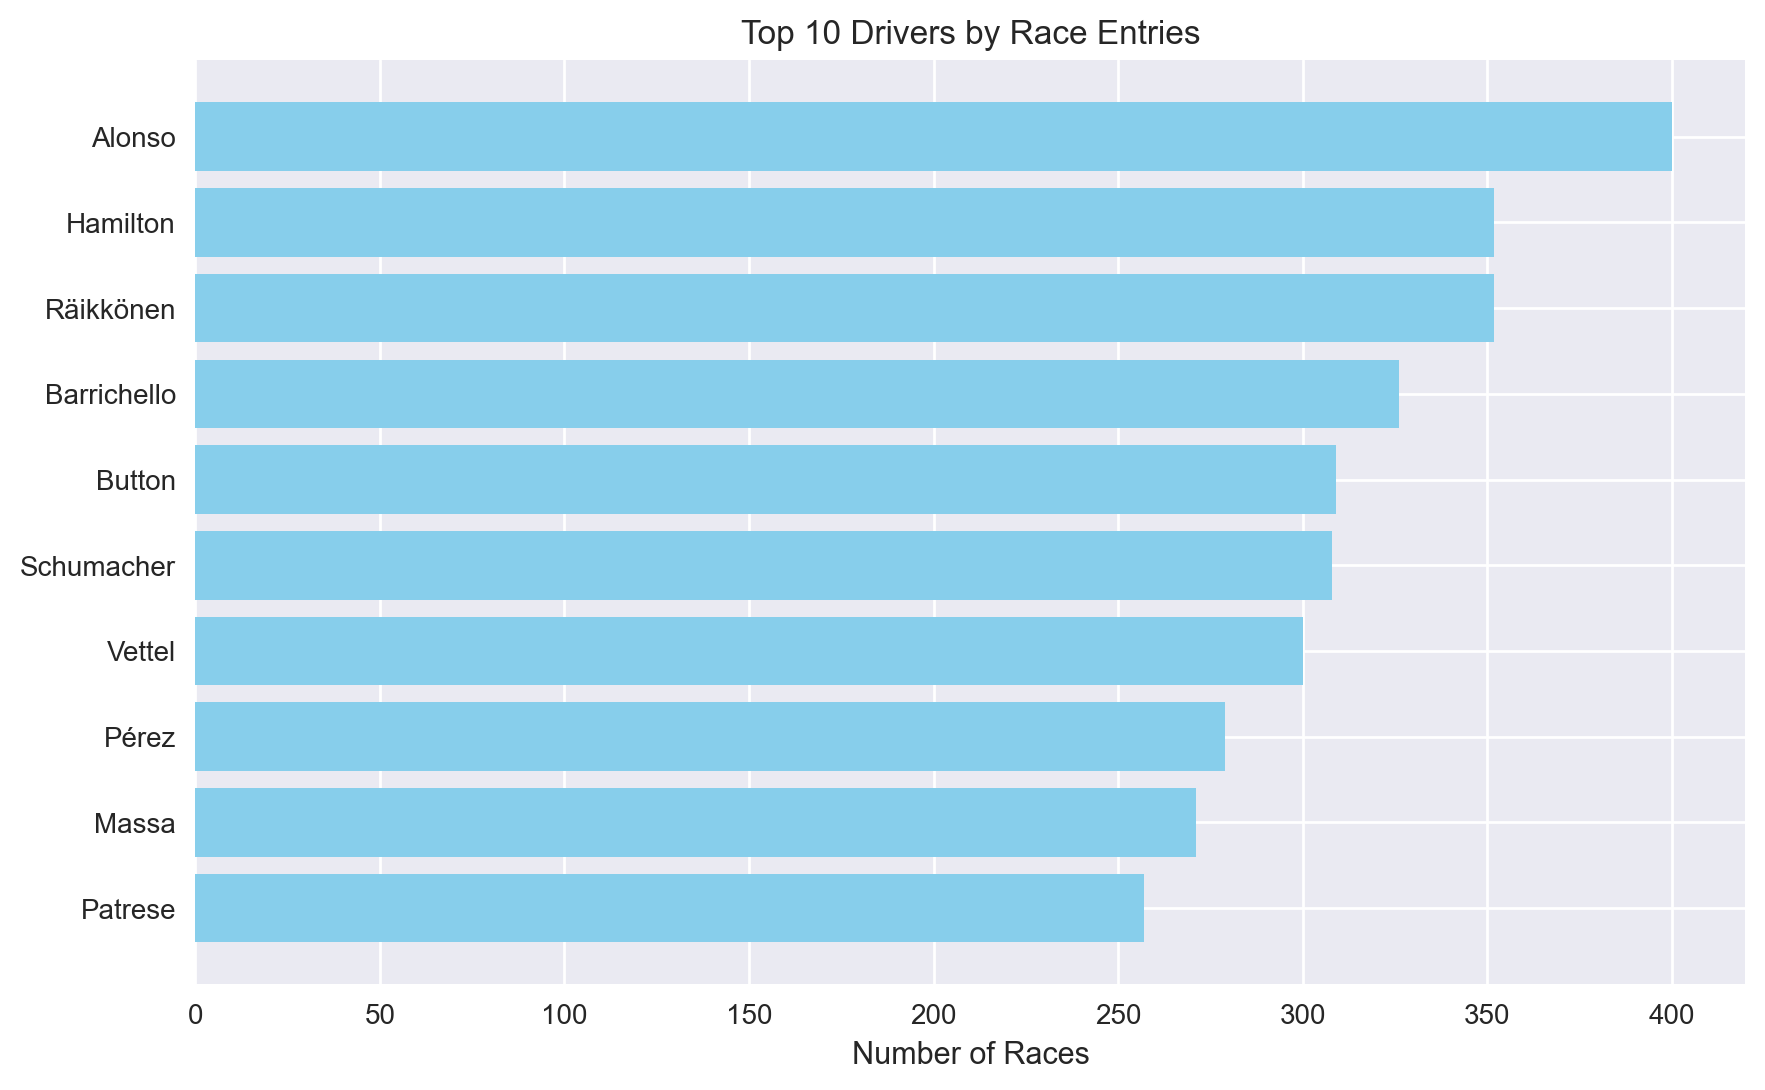

In [21]:
top_drivers = df_results['driverId'].value_counts().head(10)
top_drivers_df = top_drivers.reset_index()
top_drivers_df.columns = ['driverId', 'race_count']
top_drivers_df = top_drivers_df.merge(df_drivers[['surname']], left_on='driverId', right_index=True, how='left')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_drivers_df['surname'], top_drivers_df['race_count'], color='skyblue')
ax.set_xlabel('Number of Races')
ax.set_title('Top 10 Drivers by Race Entries')
ax.invert_yaxis()

plt.show()

### Winners of the last 5 races

Which drivers won the five most recent races?

In [22]:
winners = df_results[df_results['positionOrder'] == 1]
winners = winners.merge(df_races[['name', 'date time']], left_on='raceId', right_index=True, how='left')
winners['date time'] = pd.to_datetime(winners['date time'])
recent_winners = winners.nlargest(5, 'date time')
recent_winners = recent_winners.merge(df_drivers[['driverRef']], left_on='driverId', right_index=True, how='left')

print(recent_winners[['name', 'date time', 'driverRef']])


                              name           date time driverRef
resultId                                                        
26665       Mexico City Grand Prix 2024-10-27 20:00:00     sainz
26645     United States Grand Prix 2024-10-20 19:00:00   leclerc
26625         Singapore Grand Prix 2024-09-22 12:00:00    norris
26605        Azerbaijan Grand Prix 2024-09-15 11:00:00   piastri
26585           Italian Grand Prix 2024-09-01 13:00:00   leclerc


### All-time top 5 race winners

Build a DataFrame with forename, surname, nationality, and win count for the five drivers with the most career victories.

In [23]:
victories = df_results[df_results['positionOrder'] == 1]

victory_counts = victories['driverId'].value_counts().head(5).to_frame(name='wins')
victory_counts.index.name = 'driverId'

top_winners = victory_counts.merge(df_drivers[['forename', 'surname', 'nationality']], 
                                   left_index=True, right_index=True, how='left')

top_winners = top_winners[['forename', 'surname', 'nationality', 'wins']]

print(top_winners)


           forename     surname nationality  wins
driverId                                         
1             Lewis    Hamilton     British   105
30          Michael  Schumacher      German    91
830             Max  Verstappen       Dutch    61
20        Sebastian      Vettel      German    53
117           Alain       Prost      French    51


### Top 5 pole positions

Show the five drivers with the most pole positions (`grid == 1`), including forename, surname, nationality, and pole count.

In [24]:
top_pole_positions = (
    df_results[df_results['grid'] == 1] 
    .groupby('driverId')  
    .size()  
    .nlargest(5)  
    .to_frame(name='poles') 
    .merge(df_drivers[['forename', 'surname', 'nationality']], left_index=True, right_index=True, how='left') 
    .reset_index()  # Reset the index
    [['forename', 'surname', 'nationality', 'poles']]  
)

print(top_pole_positions)

    forename     surname nationality  poles
0      Lewis    Hamilton     British    104
1    Michael  Schumacher      German     68
2     Ayrton       Senna   Brazilian     65
3  Sebastian      Vettel      German     57
4        Max  Verstappen       Dutch     40


### Top 5 fastest laps

Show the five drivers with the most race fastest laps (`rank == 1`), including forename, surname, nationality, and fastest-lap count.

In [25]:
top_fastest_laps = (
    df_results[df_results['rank'] == 1]  # Filter rows where the driver has the fastest lap (rank == 1)
    .groupby('driverId')  # Group by driverId
    .size()  # Count fastest laps per driver
    .nlargest(5)  # Select the top 5 drivers by fastest laps
    .to_frame(name='fastestLaps')  # Convert to DataFrame and rename the column to 'fastestLaps'
    .merge(df_drivers[['forename', 'surname', 'nationality']], left_index=True, right_index=True, how='left')  # Merge with df_drivers
    .reset_index()  # Reset the index
    [['forename', 'surname', 'nationality', 'fastestLaps']]  # Select the desired columns
)

print(top_fastest_laps)

    forename     surname nationality  fastestLaps
0      Lewis    Hamilton     British           66
1       Kimi   Räikkönen     Finnish           42
2  Sebastian      Vettel      German           38
3        Max  Verstappen       Dutch           32
4   Fernando      Alonso     Spanish           25


### Average positions gained per race

Compute the average positions gained per race (`grid - position`) **for completed races only** (`statusId == 1`). Show the five top performers with forename, surname, and nationality.

In [26]:
top_positions_won = (
    df_results[df_results['statusId'] == 1]  
    .assign(pos_won=lambda df: df['grid'] - df['positionOrder']) 
    .groupby('driverId')['pos_won']  
    .mean()  
    .nlargest(5)  
    .to_frame(name='pos_won')  
    .merge(df_drivers[['forename', 'surname', 'nationality']], left_index=True, right_index=True, how='left')  
    [['forename', 'surname', 'nationality', 'pos_won']] 
)

print(top_positions_won)


          forename     surname nationality  pos_won
driverId                                           
659          Jerry        Hoyt    American     24.0
734          Bobby        Ball    American     24.0
560           Bill  Cheesbourg    American     23.0
591         George       Amick    American     23.0
613       Marshall      Teague    American     21.0


How many completed races does the top performer actually have? This matters because a tiny sample can skew the ranking.

In [27]:
races_concluded = (
    df_results[df_results['statusId'] == 1]  
    .assign(pos_won=lambda df: df['grid'] - df['positionOrder'])  
    .groupby('driverId')['pos_won']  
    .mean() 
    .nlargest(1)  
    .pipe(lambda s: df_results[(df_results['driverId'] == s.index[0]) & (df_results['statusId'] == 1)]) 
    .shape[0]  
)

print(races_concluded)


1


The raw ranking above is biased because drivers with very few finishes can dominate the top of the list. Recompute the metric restricting the sample to drivers with **at least 50 completed races**.

In [28]:
races_concluded_filtered = (
    df_results[df_results['statusId'] == 1]  
    .groupby('driverId') 
    .filter(lambda x: len(x) >= 50) 
    .assign(pos_won=lambda df: df['grid'] - df['positionOrder'])  
    .groupby('driverId')['pos_won']  
    .mean()  
    .nlargest(1)  
    .pipe(lambda s: df_results[(df_results['driverId'] == s.index[0]) & (df_results['statusId'] == 1)]) 
    .shape[0]  
)

races_concluded_filtered


61

### Loading the status descriptions

`df_results['statusId']` holds a numeric code describing how each driver/car finished each race. The lookup table lives in `data/status.csv`; load it into `df_status`.

In [29]:
df_status = pd.read_csv('data/status.csv')
df_status.head()

,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


### Most frequent DNF causes

Using `df_results` and `df_status`, build a pie chart showing the ten most frequent non-normal finish causes (everything except `statusId == 1`, "Finished"). Use a 6×6 figure size.

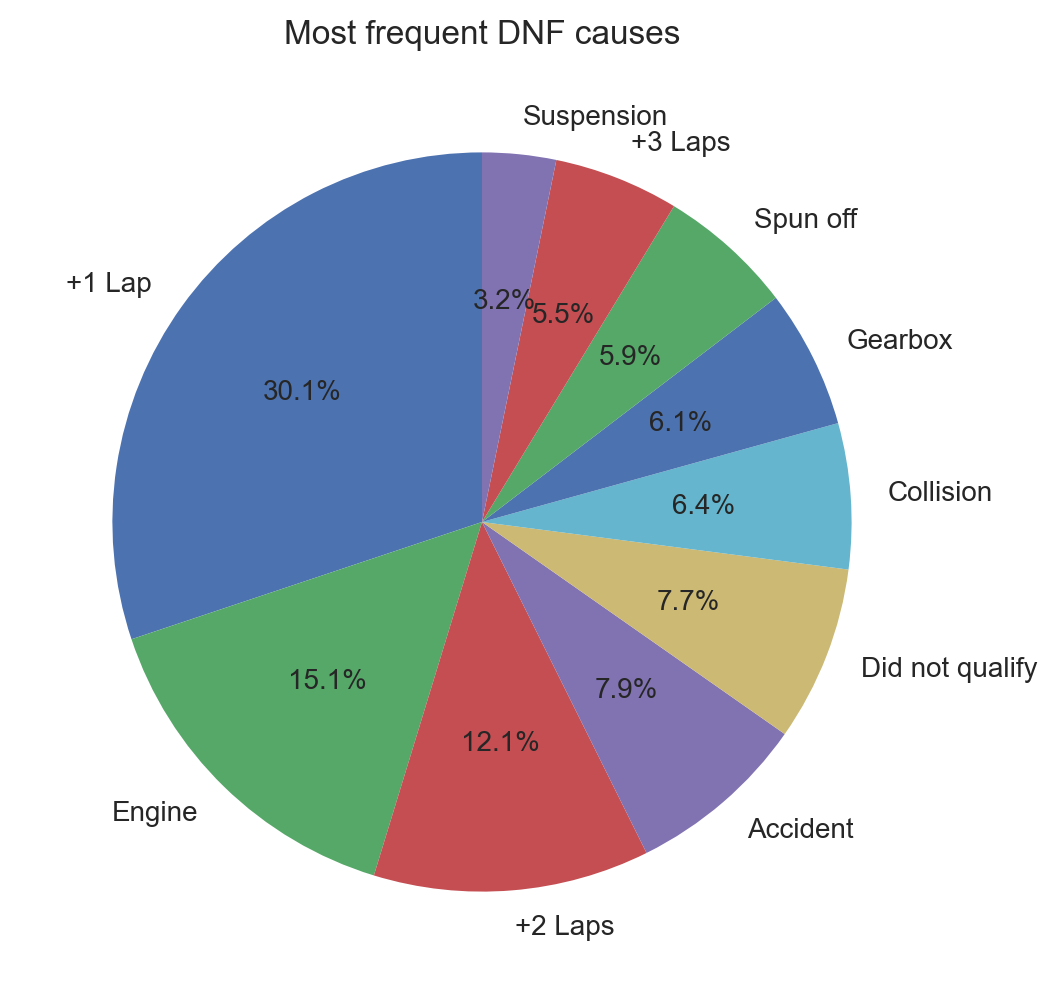

In [30]:


fig, ax = plt.subplots(figsize=(6, 6))

(
    df_results[df_results['statusId'] != 1]
    .groupby('statusId')  
    .size() 
    .nlargest(10) 
    .reset_index(name='count') 
    .merge(df_status, on='statusId', how='left')  
    .pipe(lambda df: ax.pie( 
        df['count'], 
        labels=df['status'], 
        autopct='%1.1f%%', 
        startangle=90
    ))
)

ax.set_title('Most frequent DNF causes')
plt.show()

### Filtering Fernando Alonso's completed races

Filter `df_results` to the rows corresponding to races Fernando Alonso actually finished (his `driverId` and `statusId == 1`), and store the subset in `df_results_alo`. How many completed races does he have?

In [31]:

df_results_alo = df_results[
    (df_results['driverId'] == df_drivers[df_drivers['surname'] == 'Alonso'].index[0]) &
    (df_results['statusId'] == 1)
]


num_races_alo = df_results_alo.shape[0]

print(f"Completed races: {num_races_alo}")

Completed races: 257


### Fernando Alonso's podiums

Using the `position` column, count how many podiums (1st, 2nd, 3rd) Alonso has achieved across his career.

In [32]:
# Filter Fernando Alonso's results for completed races
df_results_alo = df_results[
    (df_results['driverId'] == df_drivers[df_drivers['surname'] == 'Alonso'].index[0]) &
    (df_results['statusId'] == 1)
]

# Filter podium positions (1, 2, 3)
podiums_alo = df_results_alo[df_results_alo['position'].isin([1,2,3])]

# Count occurrences of each position
podium_counts = podiums_alo['position'].value_counts().sort_index()

print(podium_counts)

position
1.0    32
2.0    40
3.0    34
Name: count, dtype: int64


### Alonso's starting positions

How many times has Alonso started from positions 1 through 4 (the first two starting rows)?

In [33]:
starts_front_two_rows = df_results_alo[(df_results_alo['grid'] >= 1) & (df_results_alo['grid'] <= 4)]

num_occurrences = starts_front_two_rows.shape[0]

print(f"Times Fernando Alonso started from the first or second row: {num_occurrences}")

Times Fernando Alonso started from the first or second row: 90


<div align="right">
<a href="#indice">[back to contents]</a>
</div>

---

<a id="section4"></a>
## 4. Constructors

The car is the defining element of Formula 1 — the performance gap between teams is so significant that many see F1 as a competition between constructors rather than drivers.

### Loading the constructors file

Load `data/constructors.csv` into `df_constructors` using the first column as index.

In [34]:
df_constructors = pd.read_csv('data/constructors.csv', index_col=0)
df_constructors


,constructorRef,name,nationality,url
constructorId,,,,
1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso
...,...,...,...,...
210,haas,Haas F1 Team,American,http://en.wikipedia.org/wiki/Haas_F1_Team
211,racing_point,Racing Point,British,http://en.wikipedia.org/wiki/Racing_Point_F1_Team
213,alphatauri,AlphaTauri,Italian,http://en.wikipedia.org/wiki/Scuderia_AlphaTauri


In [35]:
df_constructors.info()

<class 'pandas.core.frame.DataFrame'>
Index: 212 entries, 1 to 215
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   constructorRef  212 non-null    object
 1   name            212 non-null    object
 2   nationality     212 non-null    object
 3   url             212 non-null    object
dtypes: object(4)
memory usage: 8.3+ KB


### All-time top 5 constructors by wins

Show the names and nationalities of the five constructors with the most race wins across F1 history.

In [36]:
df_top_constructors = (
    df_results[df_results['position'] == 1] 
    .groupby('constructorId')  
    .size() 
    .reset_index(name='wins') 
    .merge(df_constructors, left_on='constructorId', right_index=True)  
    [['name', 'nationality', 'wins']]  
    .sort_values(by='wins', ascending=False) 
    .head(5) 
)

print(df_top_constructors)


        name nationality  wins
5    Ferrari     Italian   249
0    McLaren     British   184
31  Mercedes      German   128
6   Red Bull    Austrian   120
2   Williams     British   114


### Alonso's points by constructor

Show the points Alonso has earned with each constructor, along with the constructor's name and nationality.

In [37]:
df_points_per_constructor = (
    df_results_alo
    .groupby('constructorId')['points']
    .sum()
    .reset_index(name='points') 
)


df_alo_with_constructors = (
    df_points_per_constructor
    .merge(df_constructors, left_on='constructorId', right_index=True)  
    [['name', 'nationality', 'points']]
    .sort_values(by='points', ascending=False))

print(df_alo_with_constructors)

             name nationality  points
2         Ferrari     Italian  1180.0
1         Renault      French   464.0
3    Aston Martin     British   255.0
0         McLaren     British   205.0
4  Alpine F1 Team      French   140.0


<div align="right">
<a href="#indice">[back to contents]</a>
</div>

---

<a id="section5"></a>
## 5. Circuits

### Loading the circuits file

`data/circuits.csv` holds one row per circuit with geographic coordinates and metadata. Load it into `df_circuits` using `circuitId` as index.

In [38]:
df_circuits = pd.read_csv('data/circuits.csv', index_col=0)

df_circuits.head()

,circuitRef,name,location,country,lat,lng,alt,url
circuitId,,,,,,,,
1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


### Five fastest circuits

Rank circuits by the mean of the top-100 `fastestLapSpeed` values recorded there. Show the five fastest.

**Note:** This is an admittedly rough proxy, but a useful one for demonstrating multi-step aggregation.

In [39]:
df_results_with_circuit = df_results.merge(
    df_races[['circuitId']], left_on='raceId', right_index=True
)

fastest_circuits = (
    df_results_with_circuit.groupby('circuitId')['fastestLapSpeed']
    .apply(lambda x: x.nlargest(100).mean())  
    .sort_values(ascending=False) 
    .head(5)  
    .reset_index(name='avg_fastestLapSpeed')  
)

df_top_circuits = fastest_circuits.merge(
    df_circuits, left_on='circuitId', right_index=True
)

df_top_circuits = df_top_circuits[['name', 'location', 'avg_fastestLapSpeed']]

print(df_top_circuits)


                             name     location  avg_fastestLapSpeed
0    Autodromo Nazionale di Monza        Monza            250.74373
1         Jeddah Corniche Circuit       Jeddah            238.73587
2             Silverstone Circuit  Silverstone            235.30426
3    Circuit de Spa-Francorchamps          Spa            234.34537
4  Las Vegas Strip Street Circuit    Las Vegas            228.72360


### Five slowest circuits

Same metric, opposite end — the five slowest circuits.

In [40]:

df_results_with_circuit = df_results.merge(
    df_races[['circuitId']], left_on='raceId', right_index=True
)

slowest_circuits = (
    df_results_with_circuit.groupby('circuitId')['fastestLapSpeed']
    .apply(lambda x: x.nsmallest(100).mean()) 
    .sort_values(ascending=True) 
    .head(5)  
    .reset_index(name='avg_fastestLapSpeed')  
)

df_bottom_circuits = slowest_circuits.merge(
    df_circuits, left_on='circuitId', right_index=True
)

df_bottom_circuits = df_bottom_circuits[['name', 'location', 'avg_fastestLapSpeed']]

print(df_bottom_circuits)


                             name     location  avg_fastestLapSpeed
0               Circuit de Monaco  Monte-Carlo            145.39755
1       Marina Bay Street Circuit   Marina Bay            159.00982
2                     Hungaroring     Budapest            177.54302
3  Shanghai International Circuit     Shanghai            183.91151
4  Circuit de Barcelona-Catalunya     Montmeló            185.31826


In [41]:

df_results_alo_with_circuit = df_results_alo.merge(
    df_races[['circuitId']], left_on='raceId', right_index=True
)

fastest_circuits_alo = (
    df_results_alo_with_circuit.groupby('circuitId')['fastestLapSpeed']
    .apply(lambda x: x.nlargest(100).mean())  
    .sort_values(ascending=False)  
    .head(5) 
    .reset_index(name='avg_fastestLapSpeed') 
)

df_top_circuits_alo = fastest_circuits_alo.merge(
    df_circuits, left_on='circuitId', right_index=True
)

df_top_circuits_alo = df_top_circuits_alo[['name', 'location', 'avg_fastestLapSpeed']]

print(df_top_circuits_alo)


                             name     location  avg_fastestLapSpeed
0    Autodromo Nazionale di Monza        Monza           243.802364
1         Jeddah Corniche Circuit       Jeddah           240.770500
2  Las Vegas Strip Street Circuit    Las Vegas           231.191000
3             Silverstone Circuit  Silverstone           227.913714
4    Circuit de Spa-Francorchamps          Spa           225.914900


### Alonso's best circuits

Which circuits produced Alonso's best average finishing position?

In [42]:
df_results_alo_with_circuit = df_results_alo.merge(
    df_races[['circuitId']], left_on='raceId', right_index=True
)

best_position_circuits = (
    df_results_alo_with_circuit.groupby('circuitId')['position']
    .mean()  # Compute mean finishing position per circuit
    .sort_values(ascending=True)  # Sort by mean position ascending
    .head(5)  # Select the 5 circuits with the best average position
    .reset_index(name='avg_position')  # Convert to DataFrame
)


df_best_position_circuits = best_position_circuits.merge(
    df_circuits, left_on='circuitId', right_index=True
)

df_best_position_circuits = df_best_position_circuits[['name', 'location', 'avg_position']]

print(df_best_position_circuits)

                             name        location  avg_position
0                   Fuji Speedway           Oyama      1.000000
1  Circuit de Barcelona-Catalunya        Montmeló      3.181818
2                     Nürburgring         Nürburg      3.250000
3     Indianapolis Motor Speedway    Indianapolis      3.500000
4    Korean International Circuit  Yeongam County      3.750000


In [43]:
!pip install folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [folium]


In [44]:
import folium

# Alternative tile providers
tiles = 'Stamen Toner'
tiles = 'OpenStreetMap'

europe_figure = folium.Figure(width=600, height=600)
europe_map = folium.Map(location=[50, 6], tiles=tiles, zoom_start=6).add_to(europe_figure)

for _,circuit in df_circuits.iterrows():
    folium.Marker([circuit['lat'], circuit['lng']], popup=circuit['name']).add_to(europe_map)
    
europe_figure

/Users/lufenufr/Downloads/mc5-m5-capstone/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


<div align="right">
<a href="#indice">[back to contents]</a>
</div>

---

<a id="section6"></a>
## 6. Fernando Alonso vs Rivals

This section compares Alonso's results against the drivers who competed in the same races he did. Extracting rival-level statistics requires a bit more data manipulation than the earlier sections — we join his race set back against the full results table.

### Listing all rivals

Return the full driver rows for every driver who ever shared a grid with Alonso.

In [45]:
...

Ellipsis

### Top 10 most-faced rivals

Store the ten drivers Alonso has faced most often in a DataFrame named `df_fa_vs`, with full driver details.

In [46]:
df_fa_vs = ...
df_fa_vs

Ellipsis

### Head-to-head table

Build a table where each row is a race Alonso completed, each column is another driver (`driverId`) who also completed that race, and each cell is that rival's finishing `position`. Store it in `df_fa_vs_other`.

In [47]:
df_fa_vs_other = ...
     
df_fa_vs_other

Ellipsis

### Top 10 rivals Alonso has beaten

From `df_fa_vs_other`, return the ten rivals Alonso has most often beaten on track.

In [48]:
# TODO: From df_fa_vs_other, compute for each rival column the number of races
# where Alonso finished ahead, then show the top 10 rivals Alonso has beaten most
# often, merged with df_drivers for readable driver details.

### Top 10 rivals who have beaten Alonso

The mirror question — which ten rivals have most often finished ahead of Alonso.

In [49]:
# TODO: Mirror of the previous cell — compute the top 10 rivals who finished
# ahead of Alonso most often, then merge with df_drivers for driver details.

<div align="right">
<a href="#indice">[back to contents]</a>
</div>

---

<a id="section7"></a>
## 7. Conclusions

This project exercised `pandas` across a 13-file relational dataset, combining filtering, grouping, multi-way joins, and `matplotlib` visualizations to answer both general competitive questions and a focused Fernando Alonso career study.

The dataset is rich — it also contains per-lap times, season standings, and constructor standings — and the analysis could be extended in multiple directions. For deeper telemetry-level work, [FastF1](https://docs.fastf1.dev) exposes car position, tyre data, and detailed timing that would support much finer-grained driving style and car performance studies.